_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: Zhidong Zhang, Yuzhe Han, Bach Nguyen

LLM Disclaimer: Github Copilot was used to help with function calling and structure prompting, Claude and Gemini were used (by different members) to help with function understanding and outcome analysis.

# Coding Lab 7 : Transcriptomics

In [ ]:
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib.pyplot as plt

# We recommend using openTSNE for experiments with t-SNE
# https://github.com/pavlin-policar/openTSNE
from openTSNE import TSNE

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2026-06-14 21:53:19 CEST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.39.0

sklearn: 1.7.2

matplotlib: 3.10.8
numpy     : 2.2.6
openTSNE  : 1.0.2
pandas    : 2.3.3

Watermark: 2.6.0



In [ ]:
plt.style.use("../matplotlib_style.txt")

# Introduction

In this notebook you are going to work with transcriptomics data, in particular single-cell RNA sequencing (scRNA-seq) data from the paper by [Harris et al. (2018)](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.2006387). They recorded the transcriptomes of 3,663 inhibitory cells in the hippocampal area CA1. Their analysis divided these cells into 49 fine-scale clusters coresponding to different cell subtypes. They asigned names to these cluster in a hierarchical fashion according to strongly expressed gene in each clusters. The figure below shows the details of their classification. 

You will first analyze some of the most relevant statistics of UMI gene counts distributions, and afterwards follow the standard pipeline in the field to produce a visualization of the data.

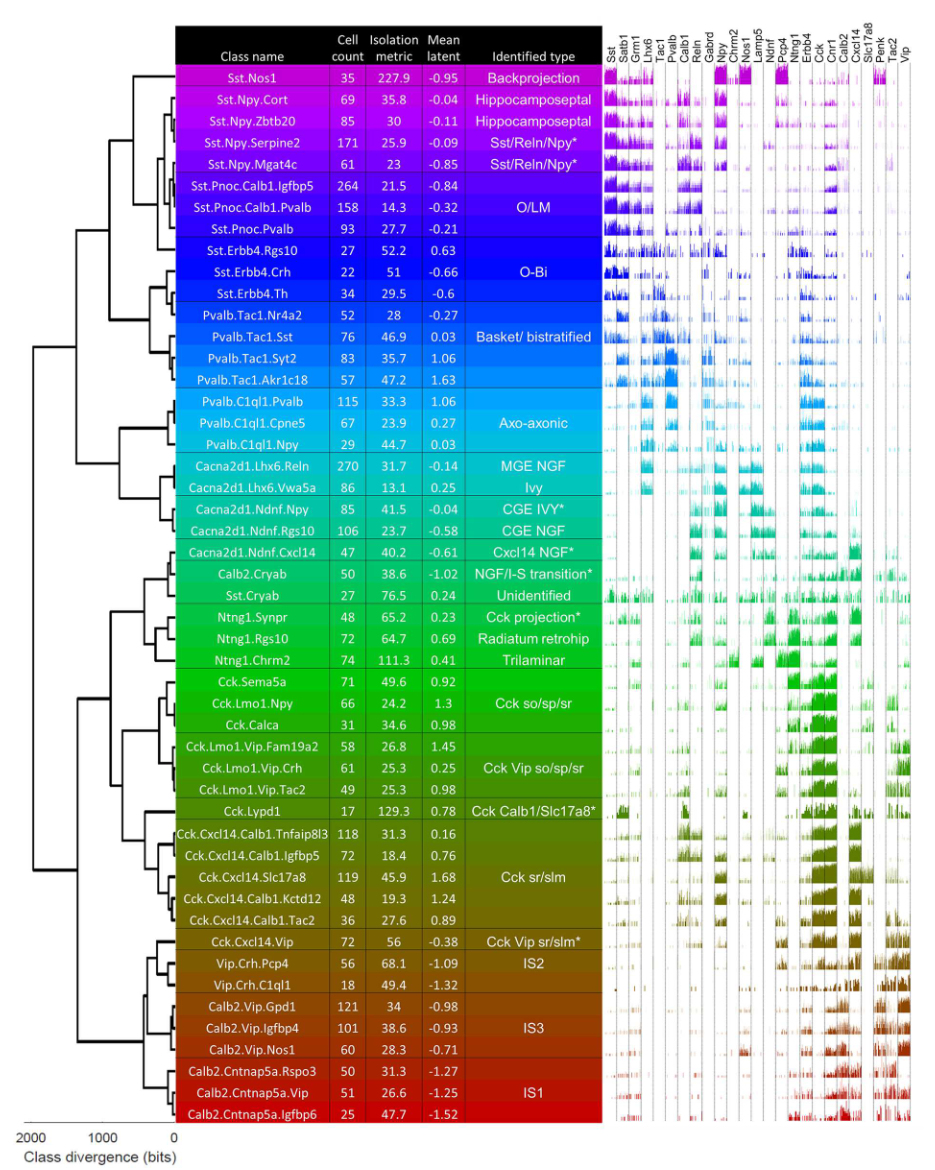

## Load data

Download the data from ILIAS, move it to the `data/` directory and unzip it there.
The read counts can be found in `counts`, with rows corresponding to cells and columns to genes.
The cluster assignments for every individual cell can be found in  `clusters`, along with the colors used in the publication in  `clusterColors`.

In [ ]:
# LOAD HARRIS ET AL DATA

# Load gene counts
data = pd.read_csv("../data/nds_cl_7/harris-data/expression.tsv.gz", sep="\t")
genes = data.values[:, 0]
cells = data.columns[1:-1]
counts = data.values[:, 1:-1].transpose().astype("int")
data = []

# Kick out all genes with all counts = 0
genes = genes[counts.sum(axis=0) > 0]
counts = counts[:, counts.sum(axis=0) > 0]
print(counts.shape)

# Load clustering results
data = pd.read_csv("../data/nds_cl_7/harris-data/analysis_results.tsv", sep="\t")
clusterNames, clusters = np.unique(data.values[0, 1:-1], return_inverse=True)

# Load cluster colors
data = pd.read_csv("../data/nds_cl_7/harris-data/colormap.txt", sep="\s+", header=None)
clusterColors = data.values

# Note: the color order needs to be reversed to match the publication
clusterColors = clusterColors[::-1]

# Taken from Figure 1 - we need cluster order to get correct color order
clusterOrder = [
    "Sst.No",
    "Sst.Npy.C",
    "Sst.Npy.Z",
    "Sst.Npy.S",
    "Sst.Npy.M",
    "Sst.Pnoc.Calb1.I",
    "Sst.Pnoc.Calb1.P",
    "Sst.Pnoc.P",
    "Sst.Erbb4.R",
    "Sst.Erbb4.C",
    "Sst.Erbb4.T",
    "Pvalb.Tac1.N",
    "Pvalb.Tac1.Ss",
    "Pvalb.Tac1.Sy",
    "Pvalb.Tac1.A",
    "Pvalb.C1ql1.P",
    "Pvalb.C1ql1.C",
    "Pvalb.C1ql1.N",
    "Cacna2d1.Lhx6.R",
    "Cacna2d1.Lhx6.V",
    "Cacna2d1.Ndnf.N",
    "Cacna2d1.Ndnf.R",
    "Cacna2d1.Ndnf.C",
    "Calb2.Cry",
    "Sst.Cry",
    "Ntng1.S",
    "Ntng1.R",
    "Ntng1.C",
    "Cck.Sema",
    "Cck.Lmo1.N",
    "Cck.Calca",
    "Cck.Lmo1.Vip.F",
    "Cck.Lmo1.Vip.C",
    "Cck.Lmo1.Vip.T",
    "Cck.Ly",
    "Cck.Cxcl14.Calb1.Tn",
    "Cck.Cxcl14.Calb1.I",
    "Cck.Cxcl14.S",
    "Cck.Cxcl14.Calb1.K",
    "Cck.Cxcl14.Calb1.Ta",
    "Cck.Cxcl14.V",
    "Vip.Crh.P",
    "Vip.Crh.C1",
    "Calb2.Vip.G",
    "Calb2.Vip.I",
    "Calb2.Vip.Nos1",
    "Calb2.Cntnap5a.R",
    "Calb2.Cntnap5a.V",
    "Calb2.Cntnap5a.I",
]

reorder = np.zeros(clusterNames.size) * np.nan
for i, c in enumerate(clusterNames):
    for j, k in enumerate(clusterOrder):
        if c[: len(k)] == k:
            reorder[i] = j
            break
clusterColors = clusterColors[reorder.astype(int)]

(3663, 17965)


In [ ]:
num_cells = cells.shape[0]
num_genes = genes.shape[0]
print("Number of cells and genes:", num_cells, num_genes)

Number of cells and genes: 3663 17965


# Task 1: Data inspection
Before we use t-SNE or any other advanced visualization methods on the data, we first want to have a closer look on the data and plot some statistics. For most of the analysis we will compare the data to a Poisson distribution.

###  1.1. Relationship between expression mean and fraction of zeros
Compute actual and predicted gene expression. The higher the average expression of a gene, the smaller fraction of cells will show a 0 count. Plot the data and explain why the plots take a particular shape or why predictions and data do not quite line up.


_(2 pts)_

In [ ]:
# ------------------------------------------------------
# Compute actual and predicted gene expression (1 pt)
# ------------------------------------------------------

# Compute the average expression for each gene
avg_counts = counts.mean(axis=0)
# Compute the fraction of zeros for each gene
frac_zero = (counts == 0).mean(axis=0)

In [ ]:
# Compute the Poisson prediction
# (what is the expected fraction of zeros in a Poisson distribution with a given mean?) -- e^{-lambda}

frac_zero_pred = np.exp(-avg_counts)
avg_order = np.argsort(avg_counts)

# counts_pred = np.random.poisson(
#     lam=avg_counts, size=(cells.shape[0], avg_counts.shape[0])
# )

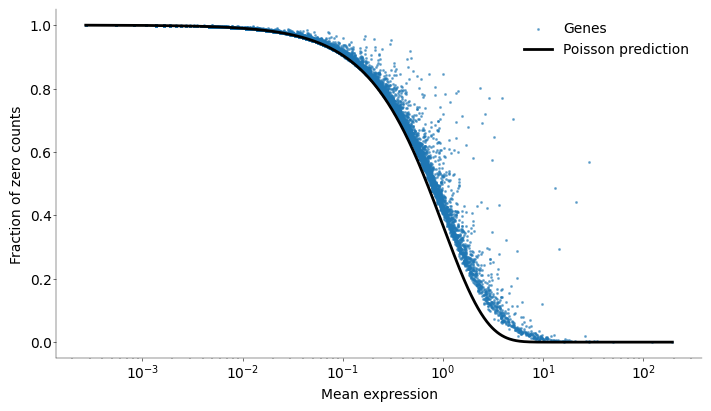

In [ ]:
# --------------------------------------------------
# plot the data and the Poisson prediction (1 pt)
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(avg_counts, frac_zero, s=5, alpha=0.5, label="Genes")
ax.plot(
    avg_counts[avg_order],
    frac_zero_pred[avg_order],
    lw=2,
    color="black",
    label="Poisson prediction",
)

ax.set_xscale("log")
ax.set_xlabel("Mean expression")
ax.set_ylabel("Fraction of zero counts")
ax.legend(loc="best")
plt.show()

### 1.2. Mean-variance relationship

If the expression follows Poisson distribution, then the mean should be equal to the variance. Plot the mean-variance relationship and interpret the plot.

_(1.5 pts)_

In [ ]:
# -------------------------------------------------------------------
# Compute the variance of the expression counts of each gene (0.5 pt)
# -------------------------------------------------------------------

var_counts = counts.var(axis=0, ddof=1)

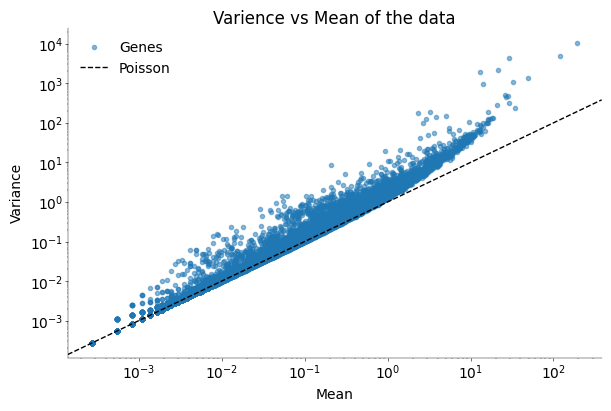

In [ ]:
# -------------------------------------------------------------
# Plot the mean-variance relationship on a log-log plot (1 pt)
# Plot the Poisson prediction as a line
# -------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(avg_counts, var_counts, alpha=0.5, label="Genes")
ax.axline((0, 0), (1, 1), linestyle="--", color="black", label="Poisson")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Mean")
ax.set_ylabel("Variance")
ax.set_title("Varience vs Mean of the data")
ax.legend()
plt.show()

### 1.3. Relationship between the mean and the Fano factor

Compute the Fano factor for each gene and make a scatter plot of expression mean vs. Fano factor in log-log coordinates, and interpret what you see in the plot. If the expression follows the Poisson distribution, then the Fano factor (variance/mean) should be equal to 1 for all genes.

_(1.5 pts)_

In [ ]:
# --------------------------------------------
# Compute the Fano factor for each gene (0.5 pt)
# --------------------------------------------

fano = var_counts / avg_counts

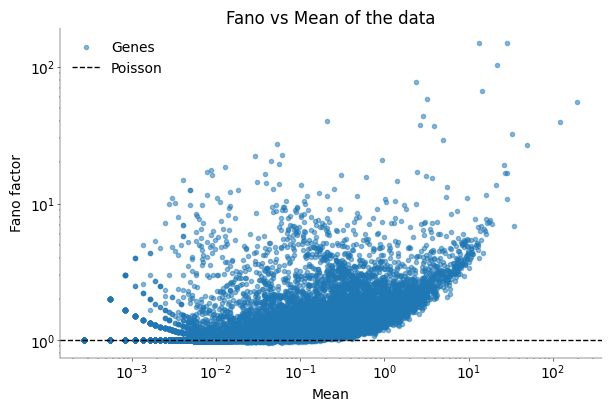

In [ ]:
# -------------------------------
# plot fano-factor vs mean (1 pt)
# incl. fano factor
# -------------------------------
# Plot a Poisson prediction as line
# Use the same style of plot as above.

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(avg_counts, fano, alpha=0.5, label="Genes")
ax.axhline(1, linestyle="--", color="black", label="Poisson")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Mean")
ax.set_ylabel("Fano factor")
ax.set_title("Fano vs Mean of the data")
ax.legend()
plt.show()

### Explanation
What is the expected for the data and why does the prediction not line up exactly in the three plots above?

_Explanation (1 pt)_

>The data shows more variant than Poisson prediction in the fraction of zeros. Also, the data shows larger Fano factor than Poisson prediction. It indicates the overdispersion of data, which can come from the biological variance of interest implying difference between cell types, or other non-Poisson technical variance such as different sequencing depth that we should remove. 

### 1.4. Histogram of sequencing depths

Different cells have different sequencing depths (sum of counts across all genes) because the efficiency can change from droplet to droplet due to some random expreimental factors. Make a histogram of sequencing depths.

_(1.5 pts)_

In [ ]:
# -------------------------------
# Compute sequencing depth (0.5 pt)
# -------------------------------
seq_deps = counts.sum(axis=1)

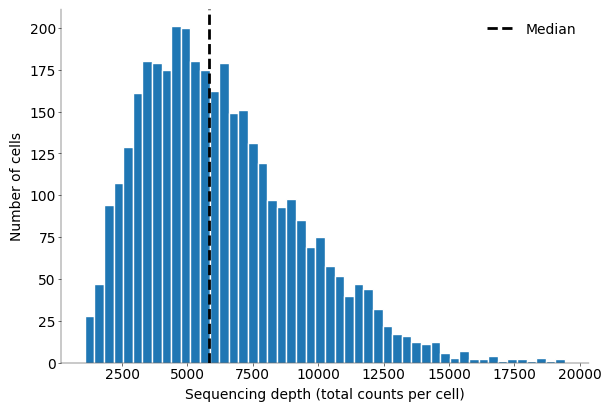

In [ ]:
# ------------------------------------------
# Plot histogram of sequencing depths (1 pt)
# ------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(seq_deps, bins=50, color="C0", edgecolor="white")
ax.axvline(np.median(seq_deps), color="black", linestyle="--", lw=2, label="Median")
ax.set_xlabel("Sequencing depth (total counts per cell)")
ax.set_ylabel("Number of cells")
ax.legend(frameon=False)
plt.show()

### 1.5. Fano factors after normalization

Normalize counts by the sequencing depth of each cell and multiply by the median sequencing depth. Then make the same expression vs Fano factor plot as above. After normalization by sequencing depth, Fano factor should be closer to 1 (i.e. variance even more closely following the mean). This can be used for feature selection.

_(2.5 pts)_

In [ ]:
# -------------------------------------------------
# compute normalized counts and fano factor (1 pt)
# -------------------------------------------------
counts_norm = counts / seq_deps[:, np.newaxis] * np.median(seq_deps)
avg_counts_norm = counts_norm.mean(axis=0)
fano_norm = counts_norm.var(axis=0, ddof=1) / avg_counts_norm

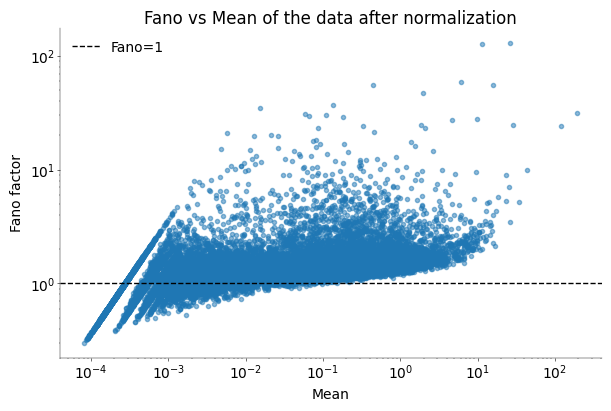

In [ ]:
# ----------------------------------------------------------
# plot normalized counts and find the top 10 genes (1 pt)
# hint: keep appropriate axis scaling in mind
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))
# add plot
ax.scatter(avg_counts_norm, fano_norm, alpha=0.5)
ax.axhline(1, linestyle="--", color="black", label="Fano=1")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Mean")
ax.set_ylabel("Fano factor")
ax.set_title("Fano vs Mean of the data after normalization")
ax.legend()

plt.show()

  gene  normalized_fano
   Sst       131.177339
   Npy       128.434088
   Vip        59.131058
   Cck        55.666252
 Cpne2        55.235396
  Pcp4        47.663087
Ptpn23        37.256418
 Pdzd9        35.064993
Malat1        31.431190
 Armc2        30.597883


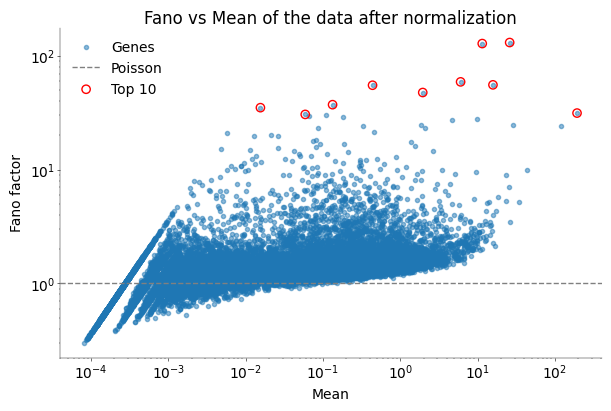

In [ ]:
# --------------------------------------------------------------------
# Find top-10 genes with the highest normalized Fano factor (0.5 pts)
# Print them sorted by the Fano factor starting from the highest
# Gene names are stored in the `genes` array
# --------------------------------------------------------------------

indices_genes_top10 = np.argsort(fano_norm)[::-1][:10]  # top 10
genes_top10 = pd.DataFrame(
    {
        "gene": genes[indices_genes_top10],
        "normalized_fano": fano_norm[indices_genes_top10],
    }
)
print(genes_top10.to_string(index=False))


fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(avg_counts_norm, fano_norm, alpha=0.5, label="Genes")
ax.axhline(1, linestyle="--", color="gray", label="Poisson")
ax.scatter(
    avg_counts_norm[indices_genes_top10],
    fano_norm[indices_genes_top10],
    marker="o",
    facecolors="none",
    edgecolors="red",
    label="Top 10",
)
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Mean")
ax.set_ylabel("Fano factor")
ax.set_title("Fano vs Mean of the data after normalization")
ax.legend()

plt.show()

# Task 2: Low dimensional visualization

In this task we will construct a two dimensional visualization of the data. First we will normalize the data with some variance stabilizing transformation and study the effect that different approaches have on the data. Second, we will reduce the dimensionality of the data to a more feasible number of dimensions (e.g. $d=50$) using PCA. And last, we will project the PCA-reduced data to two dimensions using t-SNE.

### 2.1. PCA with and without transformations

Here we look at the influence of variance-stabilizing transformations on PCA. We will focus on the following transformations: 
- Square root (`sqrt(X)`): it is a variance-stabilizing transformation for the Poisson data. 
- Log-transform (`log2(X+1)`): it is also often used in the transcriptomic community. 

We will only work with the most important genes. For that, transform the counts into normalized counts (as above) and select all genes with normalized Fano factor above 3 and remove the rest. We will look at the effect that both transformations have in the PCA-projected data by visualizing the first two components. Interpret/explain qualitatively what you see in the plot and compare the different embeddings making use of the ground truth clusters.

_(3.5 pts)_

In [ ]:
# --------------------------------
# Select important genes (0.5 pts)
# --------------------------------
masking = fano_norm > 3
genes_selected = genes[masking]
counts_selected = counts_norm[:, masking]

counts_selected.shape  # (num_cells, num_genes_selected)

(3663, 708)

In [ ]:
# --------------------------------------
# transform data and apply PCA (1 pt)
# --------------------------------------

from sklearn.decomposition import PCA

# perform PCA
# NOTE: use random_state=42

n_pca_components = 100

pca_org = PCA(n_pca_components, random_state=42)
pca_org.fit(counts_selected)
trans_counts = pca_org.fit_transform(counts_selected)

# sqrt(X)
sqrt_counts = np.sqrt(counts_selected)
pca_sqrt = PCA(n_pca_components, random_state=42)
pca_sqrt.fit(sqrt_counts)
sqrt_trans_counts = pca_sqrt.fit_transform(sqrt_counts)

# log2(X+1)
log_counts = np.log2(counts_selected + 1)
pca_log = PCA(n_pca_components, random_state=42)
pca_log.fit(log_counts)
log_trans_counts = pca_log.fit_transform(log_counts)

trans_counts.shape

(3663, 100)

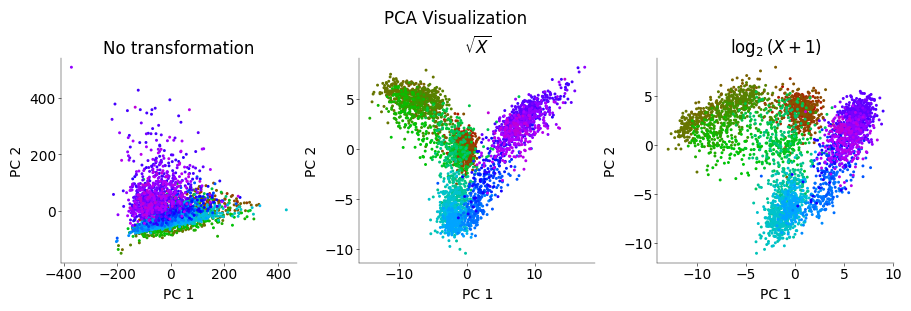

In [ ]:
# ------------------------------------------------
# plot first 2 PCs for each transformation (1 pt)
# ------------------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
# add plot

cluster_colormap = clusterColors[clusters]  # extract the groud truth colors

axs[0].scatter(trans_counts[:, 0], trans_counts[:, 1], c=cluster_colormap, s=5)
axs[1].scatter(
    sqrt_trans_counts[:, 0], sqrt_trans_counts[:, 1], c=cluster_colormap, s=5
)
axs[2].scatter(log_trans_counts[:, 0], log_trans_counts[:, 1], c=cluster_colormap, s=5)

axs[0].set_title("No transformation")
axs[1].set_title("$\\sqrt{X}$")
axs[2].set_title("$\\log_2(X+1)$")

for i in range(3):
    axs[i].set_xlabel("PC 1")
    axs[i].set_ylabel("PC 2")
plt.suptitle("PCA Visualization")
plt.show()

_Explanation (1 pt)_

> Without transformation, the 2d PCA visualization remains large value scale and several outliers dominate the PCs, which make PCs fail to capture meaningful variance across clusters. On the other hand, transformation with $\sqrt{X}$ and $\log_2(X+1)$ compress high counts and stabilize the variance, so that the PCs is less dominated by the most highly expressed genes and capture the meaningful variance across clusters. The log transform is the most aggressive compression here and usually gives the clearest separation of the known transcriptomic clusters.
>
> The latter is better obviously, in the sense that they works on the variance of interest, but also they fail to seperate cluster well. It is because 2d PCA is limited at linear transformation, which cannot capture higher dimension structure that is nonlinear.

### 2.2. tSNE with and without transformations

Now, we will reduce the dimensionality of the PCA-reduced data further to two dimensions using t-SNE. We will use only $n=50$ components of the PCA-projected data. Plot the t-SNE embedding for the three versions of the data and interpret the plots. Do the different transformations have any effect on t-SNE?

_(2.5 pts)_

In [ ]:
# -----------------------
# Perform tSNE (0.5 pts)
# -----------------------
# NOTE: use random_state=42

tsne = TSNE(
    n_components=2,
    perplexity=30,
    initialization="pca",
    metric="euclidean",
    random_state=42,
)

embedding_org = tsne.fit(trans_counts[:, :50])
embedding_sqrt = tsne.fit(sqrt_trans_counts[:, :50])
embedding_log = tsne.fit(log_trans_counts[:, :50])

embedding_org.shape

(3663, 2)

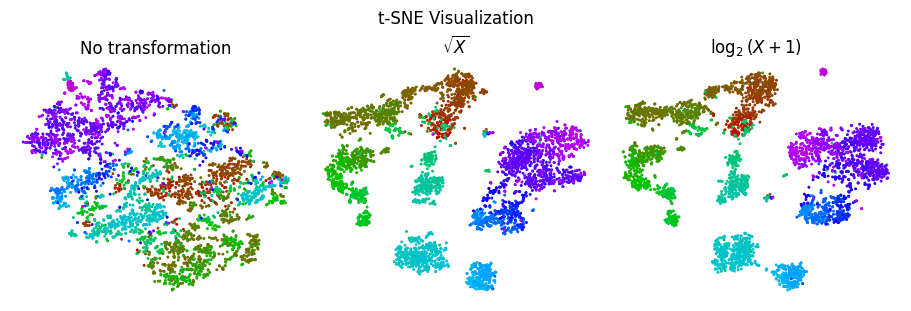

In [ ]:
# -----------------------------------------------
# plot t-SNE embedding for each dataset (1 pt)
# -----------------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
# add plot

axs[0].scatter(embedding_org[:, 0], embedding_org[:, 1], c=cluster_colormap, s=5)
axs[1].scatter(embedding_sqrt[:, 0], embedding_sqrt[:, 1], c=cluster_colormap, s=5)
axs[2].scatter(embedding_log[:, 0], embedding_log[:, 1], c=cluster_colormap, s=5)

axs[0].set_title("No transformation")
axs[1].set_title("$\\sqrt{X}$")
axs[2].set_title("$\\log_2(X+1)$")

for i in range(3):
    axs[i].axis("off")
plt.suptitle("t-SNE Visualization")
plt.show()

_Answer (1 pt)_
> It can be seen that t-SNE keep the high-dimensional structure much better than PCA, so the known clusters apear as compact groups in all three embeddings. Without transformations, the visualization can still somewhat shows the cluster relation, better than PCA but still not satisfying. It may due to that outliers of one cluster happens to be closer to members of another cluster, leading to the overlap. On the other hand, transformation make t-SNE almost perfect to shows the true clusters, while there are still some points overlapping with other clusters. Among the two methods, $\log_2(X+1)$ transformation is slightly better than $\sqrt X$.

### 2.3. Leiden clustering

Now we will play around with some clustering and see whether the clustering methods can produce similar results to the original clusters from the publication. We will apply Leiden clustering (closely related to the Louvain clustering), which is standard in the field and works well even for very large datasets. 

Choose one representation of the data (best transformation based in your results from the previous task) to use further in this task and justify your choice. Think about which level of dimensionality would be sensible to use to perform clustering. Visualize in the two-dimensional embedding the resulting clusters and compare to the original clusters. 

_(2.5 pts)_

In [ ]:
# To run this code you need to install leidenalg and igraph
# conda install -c conda-forge python-igraph leidenalg
# %conda install -c conda-forge python-igraph leidenalg
import igraph as ig
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
import leidenalg as la

In [ ]:
# Define some contrast colors
clusterCols = pd.read_csv(
    "../data/nds_cl_7/cluster_colormap.txt",
    sep=",",
    header=None,
    usecols=[0],  # only the first column
)
clusterCols = np.array(clusterCols.values.flatten())

In [ ]:
# ------------------------------------------------------
# create graph and run leiden clustering on it (0.5 pts)
# hint: use `la?`, `la.find_partition?` and `ig.Graph?`
# to find out more about the provided packages.
# ------------------------------------------------------

# Construct kNN graph with k=15

A = kneighbors_graph(
    embedding_log, n_neighbors=15, mode="connectivity"
)  # binary matrix

# sources, targets = A.nonzero() # to get the source-target pairs of all edges

# Transform it into an igraph object
A = ig.Graph.Adjacency(A.toarray(), mode="directed")


# Run Leiden clustering
# you can use `la.RBConfigurationVertexPartition` as the partition type
# use seed=42 for all runs to make sure you get the same results as us
partition = la.find_partition(A, la.RBConfigurationVertexPartition, seed=42)

print("Number of cluster: ", len(partition))

Number of cluster:  27


Text(0.5, 1.0, 'Leiden Clustering (# 27)')

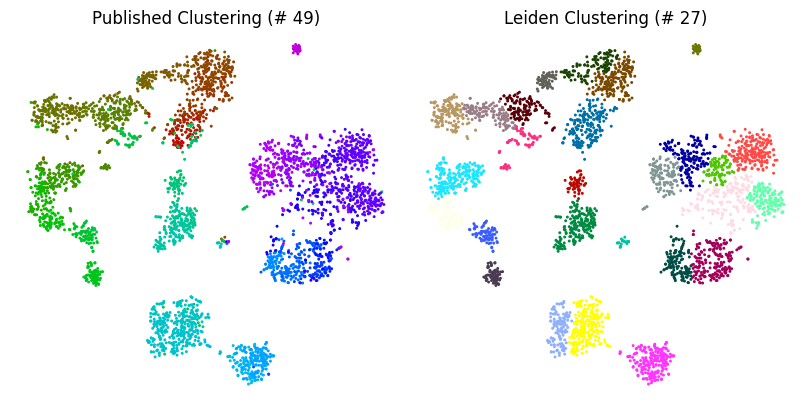

In [ ]:
# --------------------------
# Plot the results (1 pt)
# --------------------------

# Using the log transformation embedding

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(embedding_log[:, 0], embedding_log[:, 1], c=cluster_colormap, s=5)
axes[0].axis("off")
axes[0].set_title(f"Published Clustering (# {len(np.unique(clusters))})")

axes[1].scatter(
    embedding_log[:, 0], embedding_log[:, 1], c=clusterCols[partition.membership], s=5
)
axes[1].axis("off")
axes[1].set_title(f"Leiden Clustering (# {len(partition)})")

_Explanation / Justification (1 pt)_

> Here the 2D t-SNE embedding of the log-transformed normalized counts is used for clustering. The graph-based clustering recovers broad regions that agree with the published labels, but it does not reproduce every fine subtype exactly because the publication labels come from a richer analysis pipeline and a single graph-resolution parameter cannot perfectly match all hierarchical cluster boundaries. As a result, the Leiden clustering would looks slight cleaner than the published one.

### 2.4. Change the clustering resolution

The number of clusters can be changed by modifying the resolution parameter. How many clusters did we get with the default value? Change the resolution parameter to yield 2x more and 2x fewer clusters
Plot all three results as t-SNE overlays (same as above).

_(1.5 pts)_

In [ ]:
# --------------------------------------------------------------------
# run the clustering for 3 different resolution parameters (0.5 pts)
# use seed=42 for all runs to make sure you get the same results as us
# --------------------------------------------------------------------
resolutions = [0.2, 1, 3.5]
partitions = []

for resol in resolutions:
    partition_i = la.find_partition(
        A,
        la.RBConfigurationVertexPartition,
        resolution_parameter=resol,
        seed=42,
    )
    print("Number of cluster: ", len(partition_i))
    partitions.append(partition_i)

Number of cluster:  16
Number of cluster:  27
Number of cluster:  54


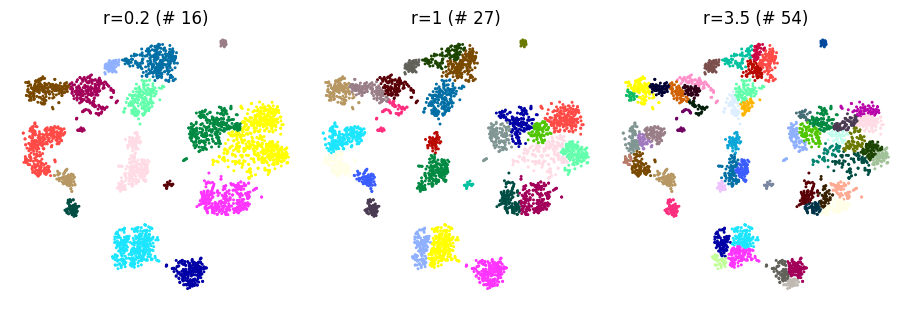

In [ ]:
# --------------------------
# Plot the results (1 pt)
# --------------------------

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
# add plot
for i, ax in enumerate(axs):
    par = partitions[i]
    ax.scatter(
        embedding_log[:, 0], embedding_log[:, 1], c=clusterCols[par.membership], s=5
    )
    ax.set_title(f"r={resolutions[i]} (# {len(par)})")
    ax.axis("off")